In [7]:
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display

In [8]:
RESULTS_PATH = "swin2_gated_bbl_0_results.json"

Best validation epoch: 4  (avg_bacc = 0.7312)


/var/folders/t4/1721vj097g5355jrnjbw96qc0000gn/T/ipykernel_2352/1627190405.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


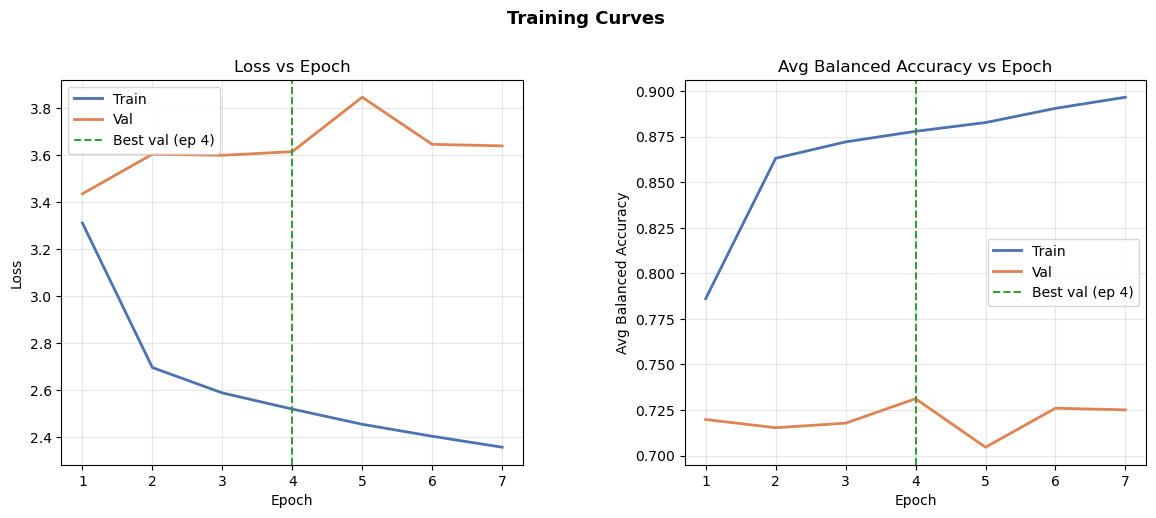


── Summary: Best Validation vs Test ──────────────────────────────


,Best Val (Ep 4),Test
Metric,,
Loss,3.6142,5.0842
Accuracy,86.29%,81.47%
Balanced Accuracy,73.12%,71.64%
mAP,54.33%,62.59%


,Best Val (Ep 4),Test
Metric,,
Accuracy C1,85.84%,79.66%
Accuracy C2,88.76%,86.44%
Accuracy C3,84.26%,78.32%
Balanced Accuracy C1,78.02%,72.37%
Balanced Accuracy C2,75.46%,74.80%
Balanced Accuracy C3,65.88%,67.76%
AP C1,57.16%,60.66%
AP C2,52.32%,62.98%
AP C3,53.51%,64.14%


In [9]:
with open(RESULTS_PATH) as f:
    results = json.load(f)

# ── 2. Parse keys into (epoch, split) ────────────────────────────────────────
train_rows, val_rows, test_row = [], [], None

for key, metrics in results.items():
    m = re.match(r"Epoch (\d+) (Train|Val|Test)", key, re.IGNORECASE)
    if not m:
        # Handle a bare "Test" key if present
        if re.match(r"^test$", key, re.IGNORECASE):
            test_row = metrics
        continue
    epoch, split = int(m.group(1)), m.group(2).lower()
    row = {"epoch": epoch, **{k: v for k, v in metrics.items() if k != "saved"}}
    if split == "train":
        train_rows.append(row)
    elif split == "val":
        val_rows.append(row)
    elif split == "test":
        test_row = metrics          # last / only test entry wins

train_df = pd.DataFrame(train_rows).sort_values("epoch").reset_index(drop=True)
val_df   = pd.DataFrame(val_rows).sort_values("epoch").reset_index(drop=True)

# ── 3. Identify best-val epoch (highest avg_bacc) ────────────────────────────
best_idx      = val_df["avg_bacc"].idxmax()
best_val_row  = val_df.loc[best_idx]
best_epoch    = int(best_val_row["epoch"])
print(f"Best validation epoch: {best_epoch}  (avg_bacc = {best_val_row['avg_bacc']:.4f})")

# ── 4. Plots ─────────────────────────────────────────────────────────────────
epochs = train_df["epoch"].values

fig = plt.figure(figsize=(14, 5))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

TRAIN_COL = "#4C72B0"
VAL_COL   = "#DD8452"
BEST_COL  = "#2ca02c"

# — Loss —
ax1 = fig.add_subplot(gs[0])
ax1.plot(epochs, train_df["loss"], color=TRAIN_COL, lw=2, label="Train")
ax1.plot(epochs, val_df["loss"],   color=VAL_COL,   lw=2, label="Val")
ax1.axvline(best_epoch, color=BEST_COL, ls="--", lw=1.4, label=f"Best val (ep {best_epoch})")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Loss vs Epoch"); ax1.legend(); ax1.grid(alpha=0.3)

# — Balanced Accuracy —
ax2 = fig.add_subplot(gs[1])
ax2.plot(epochs, train_df["avg_bacc"], color=TRAIN_COL, lw=2, label="Train")
ax2.plot(epochs, val_df["avg_bacc"],   color=VAL_COL,   lw=2, label="Val")
ax2.axvline(best_epoch, color=BEST_COL, ls="--", lw=1.4, label=f"Best val (ep {best_epoch})")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Avg Balanced Accuracy")
ax2.set_title("Avg Balanced Accuracy vs Epoch"); ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle("Training Curves", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── 5. Summary table: best-val vs test ───────────────────────────────────────
# (label, key, is_percentage)
GENERAL_METRICS = [
    ("Loss",               "loss",          False),
    ("Accuracy",           "avg_accuracy",  True),
    ("Balanced Accuracy",  "avg_bacc",      True),
    ("mAP",                "mAP",           True),
]
 
PER_CLASS_METRICS = [
    ("Accuracy C1",          "accuracy_C1",      True),
    ("Accuracy C2",          "accuracy_C2",      True),
    ("Accuracy C3",          "accuracy_C3",      True),
    ("Balanced Accuracy C1", "bal_accuracy_C1",  True),
    ("Balanced Accuracy C2", "bal_accuracy_C2",  True),
    ("Balanced Accuracy C3", "bal_accuracy_C3",  True),
    ("AP C1",                "ap_C1",            True),
    ("AP C2",                "ap_C2",            True),
    ("AP C3",                "ap_C3",            True),
]
 
VAL_COL_NAME  = f"Best Val (Ep {best_epoch})"
TEST_COL_NAME = "Test"
 
def build_section_df(metric_list):
    rows = {}
    for label, key, is_pct in metric_list:
        def fmt(val):
            if not pd.notna(val):
                return "—"
            return f"{val*100:.2f}%" if is_pct else f"{val:.4f}"
        bv = best_val_row.get(key, float("nan"))
        tv = test_row.get(key, float("nan")) if test_row else float("nan")
        rows[label] = {VAL_COL_NAME: fmt(bv), TEST_COL_NAME: fmt(tv)}
    df = pd.DataFrame(rows).T
    df.index.name = "Metric"
    return df
 
general_df   = build_section_df(GENERAL_METRICS)
per_class_df = build_section_df(PER_CLASS_METRICS)
 
TABLE_STYLES = [
    {"selector": "caption",  "props": [("font-size", "13px"), ("font-weight", "bold"),
                                        ("text-align", "left"), ("padding-bottom", "6px")]},
    {"selector": "th",       "props": [("background-color", "#000000"), ("font-weight", "bold"),
                                        ("text-align", "center")]},
    {"selector": "td",       "props": [("text-align", "center"), ("padding", "4px 12px")]},
    {"selector": "th.row_heading", "props": [("text-align", "left")]},
]
 
print("\n── Summary: Best Validation vs Test ──────────────────────────────")
display(general_df.style
    .set_caption("Overall Results")
    .set_table_styles(TABLE_STYLES)
)
display(per_class_df.style
    .set_caption("Per-Class Results")
    .set_table_styles(TABLE_STYLES)
)